# **MAT 4373: Project** </br> L1 vs. L2 regularization

## **Group members**
**Group 3**

| Name | Student ID |
|------|------------|
| Zixin Fan | 300296371 |
|  |  | 
|  |  | 
|  |  | 

## **Task distribution**
- Zixin Fan
  - Synthetic dataset generation and experimental setup.
  - Analysis of predictive performance, parameter estimation accuracy, and variable selection performance.
  - High-dimensional regime (d > n) – analysis of model behaviour, explanation of ridge uniqueness and lasso sparsity, and evaluation of prediction error and support recovery.
  - Slides preparation and participation in code testing and validation.
-

## **Libraries and Packages**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from data_generation import generate_sparse_linear_data
from data_generation import generate_toeplitz_covariance
from data_generation import generate_correlated_sparse_linear_data

## **Synthetic dataset generation**

### **Dataset 1: An independent Gaussian design**

We generate synthetic data from a sparse linear model:

y = Xw* + ε

where:
- X ~ N(0, I), a design matrix with independent features,
- w* is sparse, with only s << d nonzero entries,
- ε ~ N(0, σ²), Gaussian noise.

**Goal**  
This dataset serves as a baseline under ideal conditions.  
We evaluate:
- prediction accuracy of Ridge and Lasso,
- parameter estimation accuracy,
- support recovery when the true model is sparse.

#### **generate_sparse_linear_data:**
- sample size: n = 1000

    Larger n generally improves estimation accuracy and prediction performance.

- number of features: d = 50

    Higher d increases model complexity and makes variable selection more challenging.

- number of nonzero coefficients in w*: s = 5

    The sparsity level is s/d = 5/50 = 0.1, meaning only a small subset of variables are relevant.

- standard deviation of the Gaussian noise: sigma=1.0

    Larger sigma leads to noisier observations and makes recovery harder.

- magnitude of the nonzero coefficients in w*: signal = 2.0

     Stronger signal makes it easier to identify the true support.

- seed for reproducibility: random_seeds = 100

In [44]:
# baseline dataset generated using default parameter settings
X,y,w_true,support=generate_sparse_linear_data()

#### **Check of Generated Data**

In [45]:
print("X shape:",X.shape)
print("y shape:",y.shape)
print("nonzero positions:",support)
print("number of nonzero coefficients:",np.sum(w_true!=0))
print("w_true:",w_true)

X shape: (1000, 50)
y shape: (1000,)
nonzero positions: [10  3  5 18 12]
number of nonzero coefficients: 5
w_true: [ 0.  0.  0. -2.  0.  2.  0.  0.  0.  0.  2.  0. -2.  0.  0.  0.  0.  0.
  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]


#### **Visualization of True Coefficients**

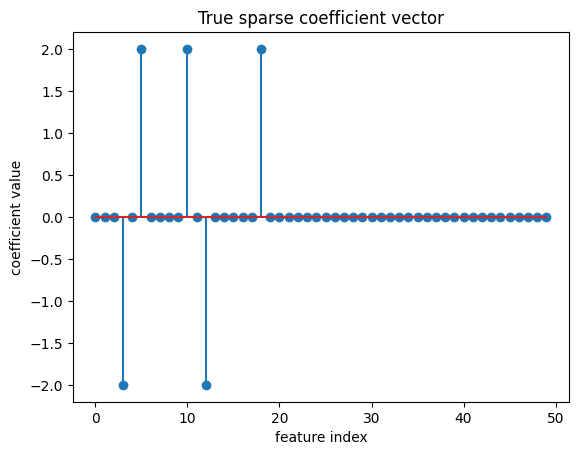

In [46]:
plt.stem(w_true)
plt.title("True sparse coefficient vector")
plt.xlabel("feature index")
plt.ylabel("coefficient value")
plt.show()

The plot shows that only 5 coefficients are nonzero, while the remaining coefficients are exactly zero, confirming the sparsity of the true parameter vector.

Using the data generation procedure described above, we obtain a synthetic dataset (X, y), along with the true coefficient vector w* and its support (i.e. nonzero positions), which will serve as the ground truth for evaluating prediction accuracy.

### **Dataset 2: A correlated Gaussian design**

We generate synthetic data using the same sparse linear model:

y = Xw* + ε

However, unlike Dataset 1, we introduce correlation among features:

- X ~ N(0, Σ), where Σ is a covariance matrix,
- w* is sparse,
- ε ~ N(0, σ²).

To model correlation, we use a Toeplitz covariance structure:
Σ_{jk} = ρ^{|j-k|}

This means nearby features are more strongly correlated.

**Goal**  
We investigate:
- whether Lasso’s variable selection deteriorates under correlated predictors,
- whether Ridge provides more stable estimates in the presence of correlation.

#### **generate_toeplitz_covariance:**

- number of features: d = 50

    Defines the dimension of the covariance matrix.

- correlation strength: rho = 0.5

    Controls how strongly features are correlated. Larger rho leads to stronger correlation.

- output: Σ ∈ R^{d×d}

    A Toeplitz covariance matrix where Σ_{jk} = ρ^{|j-k|}.

To introduce correlation among features, we adopt a Toeplitz covariance structure defined as Σ_{jk} = ρ^{|j-k|}.

This structure is commonly used in statistical learning and high-dimensional settings because it captures a realistic scenario where features that are closer in index tend to be more strongly correlated, while the correlation decays as the distance increases.

The parameter ρ ∈ (-1,1) controls the strength of dependence. Larger values of ρ lead to stronger correlations, allowing us to systematically vary the difficulty of the estimation problem.

Importantly, the Toeplitz covariance matrix is positive semidefinite for |ρ| < 1, which guarantees that the multivariate normal distribution is valid.

This design is particularly useful for our study, as correlated features are known to affect the behaviour of regularization methods:
- Ridge regression tends to handle correlated predictors more smoothly,
- while Lasso may struggle with variable selection when features are highly correlated.

Therefore, this setting enables us to evaluate the robustness of both methods under realistic and challenging conditions.


In [47]:
Sigma=generate_toeplitz_covariance(d=50,rho=0.5)
Sigma

array([[1.00000000e+00, 5.00000000e-01, 2.50000000e-01, ...,
        7.10542736e-15, 3.55271368e-15, 1.77635684e-15],
       [5.00000000e-01, 1.00000000e+00, 5.00000000e-01, ...,
        1.42108547e-14, 7.10542736e-15, 3.55271368e-15],
       [2.50000000e-01, 5.00000000e-01, 1.00000000e+00, ...,
        2.84217094e-14, 1.42108547e-14, 7.10542736e-15],
       ...,
       [7.10542736e-15, 1.42108547e-14, 2.84217094e-14, ...,
        1.00000000e+00, 5.00000000e-01, 2.50000000e-01],
       [3.55271368e-15, 7.10542736e-15, 1.42108547e-14, ...,
        5.00000000e-01, 1.00000000e+00, 5.00000000e-01],
       [1.77635684e-15, 3.55271368e-15, 7.10542736e-15, ...,
        2.50000000e-01, 5.00000000e-01, 1.00000000e+00]], shape=(50, 50))

#### **generate_correlated_sparse_linear_data:**
- sample size: n = 1000

    Number of observations.

- number of features: d = 50

    Dimensionality of the feature space.

- number of nonzero coefficients in w*: s = 5

    Only a small subset of variables are relevant.

- standard deviation of the Gaussian noise: sigma = 1.0

    Controls noise level in the response.

- signal strength: signal = 2.0

    Determines the magnitude of nonzero coefficients.

- correlation strength: rho = 0.5

    Controls the dependency between features through the covariance matrix Σ.

- seed for reproducibility: random_seeds = 100

In [48]:
rho=0.5
X_corr,y_corr,w_true_corr,support_corr,Sigma=generate_correlated_sparse_linear_data(rho=rho)

#### **Check of Generated Data**

In [49]:
print("X shape:",X_corr.shape)
print("y shape:",y_corr.shape)
print("nonzero positions:",support_corr)
print("number of nonzero coefficients:",np.sum(w_true_corr!=0))
print("Sigma shape:",Sigma.shape)

X shape: (1000, 50)
y shape: (1000,)
nonzero positions: [10  3  5 18 12]
number of nonzero coefficients: 5
Sigma shape: (50, 50)


#### **Visualization of True Coefficients**

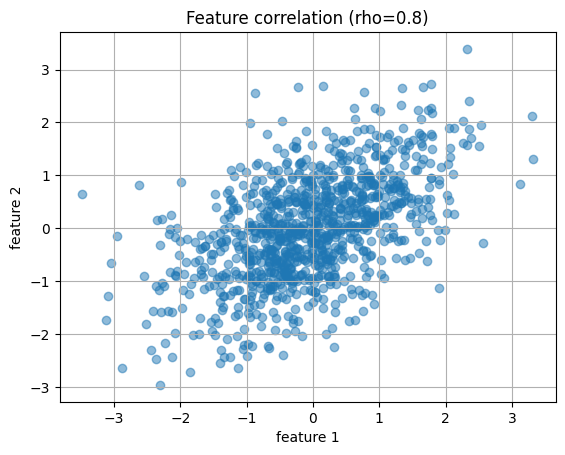

In [50]:
plt.scatter(X_corr[:,0], X_corr[:,1], alpha=0.5)
plt.title(f"Feature correlation (rho=0.5)")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.grid()
plt.show()

To illustrate the correlation structure, we visualize the first two features of X. 
We observe that as ρ increases, the features become more strongly correlated.

### **Dataset 3: High-dimensional Sparse Design (d > n)**

We consider the high-dimensional regime where the number of features exceeds the number of observations (d > n).

We generate data using the same sparse linear model:

y = Xw* + ε

but with d > n, making the problem underdetermined.

In this setting, the design matrix X is not full rank, and the ordinary least squares solution is not unique.

**Goal**  
We study:
- the necessity of regularization in high-dimensional settings,
- why Ridge yields a unique solution,
- why Lasso produces sparse solutions,
- how prediction accuracy and support recovery behave when d > n.

In [51]:
# use the same generation function, but set d > n
X_hd, y_hd, w_true_hd, support_hd = generate_sparse_linear_data(
    n=50,
    d=200,
    s=5,
    sigma=1.0,
    signal=2.0
)

#### **Check of Generated Data**

In [52]:
print("X shape:", X_hd.shape)
print("y shape:", y_hd.shape)
print("nonzero positions:",support_hd)
print("number of nonzero coefficients:", np.sum(w_true_hd != 0))

X shape: (50, 200)
y shape: (50,)
nonzero positions: [ 61 117  54 189 184]
number of nonzero coefficients: 5


#### **Visualization of True Coefficients**

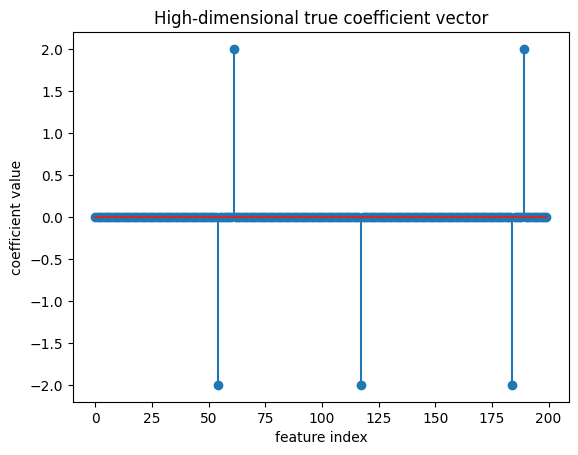

In [53]:
plt.stem(w_true_hd)
plt.title("High-dimensional true coefficient vector")
plt.xlabel("feature index")
plt.ylabel("coefficient value")
plt.show()

Compared to the independent Gaussian design, the high-dimensional setting (d > n) contains many more features while keeping the same number of nonzero coefficients. This results in a much sparser signal relative to the ambient dimension, making it more challenging to recover the true support. This setting is particularly useful for evaluating how regularization methods behave in underdetermined problems.

The three synthetic datasets are constructed to directly reflect the requirements of the project and to isolate key factors affecting regularization methods.

In particular:
- Dataset 1 (independent Gaussian design) serves as a baseline where features are uncorrelated.
- Dataset 2 (correlated Gaussian design) introduces controlled feature dependence using a Toeplitz covariance structure.
- Dataset 3 (high-dimensional design, d > n) represents an underdetermined setting where regularization becomes essential.

This design enables a systematic investigation of how sample size (n), dimensionality (d), sparsity level (s), noise level (σ), and correlation (ρ) influence:
- prediction accuracy,
- parameter estimation,
- and support recovery.

## Experimental Study under Varying Data Conditions

# References
- Marcussena. (n.d.). Synthetic data generation [GitHub repository]. 
https://github.com/Marcussena/Synthetic-data-generation
- NumPy Developers. (n.d.). numpy.random.multivariate_normal. 
  https://numpy.org/doc/2.2/reference/random/generated/numpy.random.multivariate_normal.html
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). 
  The Elements of Statistical Learning (2nd ed.). Springer.